# Business Understanding

## Project Domain

## Problem Statements

## Goals

## Solution Statements

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"syakiraadha","key":"99e310ab8c639e7c690cfe31394923b3"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d uciml/iris --force

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
  0% 0.00/3.60k [00:00<?, ?B/s]
100% 3.60k/3.60k [00:00<00:00, 13.6MB/s]


In [6]:
!mkdir iris
!unzip iris.zip -d iris
!ls iris

mkdir: cannot create directory ‘iris’: File exists
unzip:  cannot find or open iris.zip, iris.zip.zip or iris.zip.ZIP.
database.sqlite  Iris.csv


## Import Library yang dibutuhkan

In [7]:
#library untuk model ANN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Exploratory Data Analysis

In [8]:
df = pd.read_csv('iris/Iris.csv')

In [9]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0:'setosa', 1:'versicolor', 2:'virginica'})

In [10]:
print(df.head())
print(df.info())
print(df.describe())
print(df['species'].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float

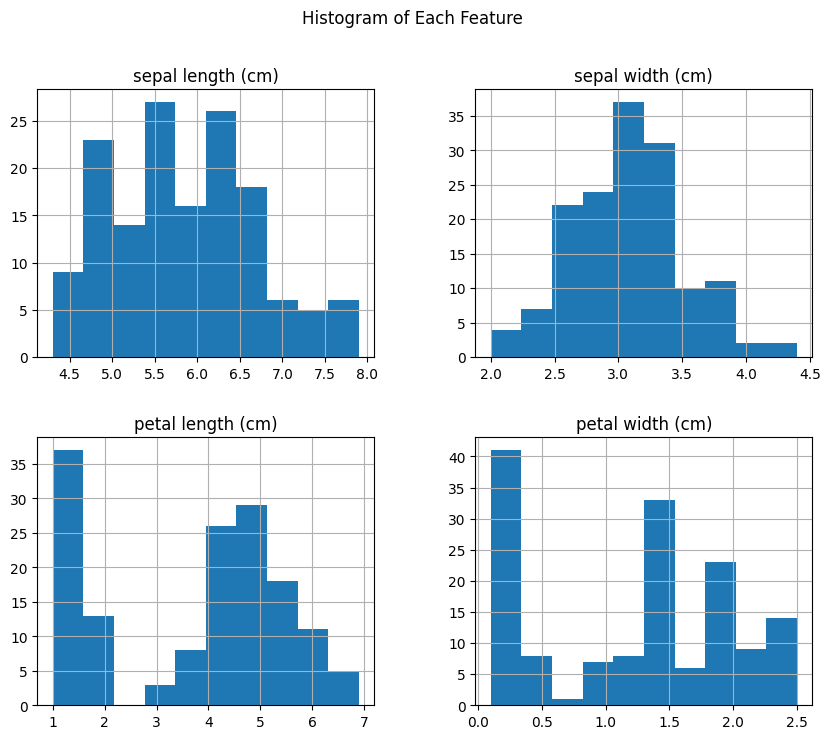

In [11]:
df.hist(figsize=(10, 8))
plt.suptitle('Histogram of Each Feature')
plt.show()

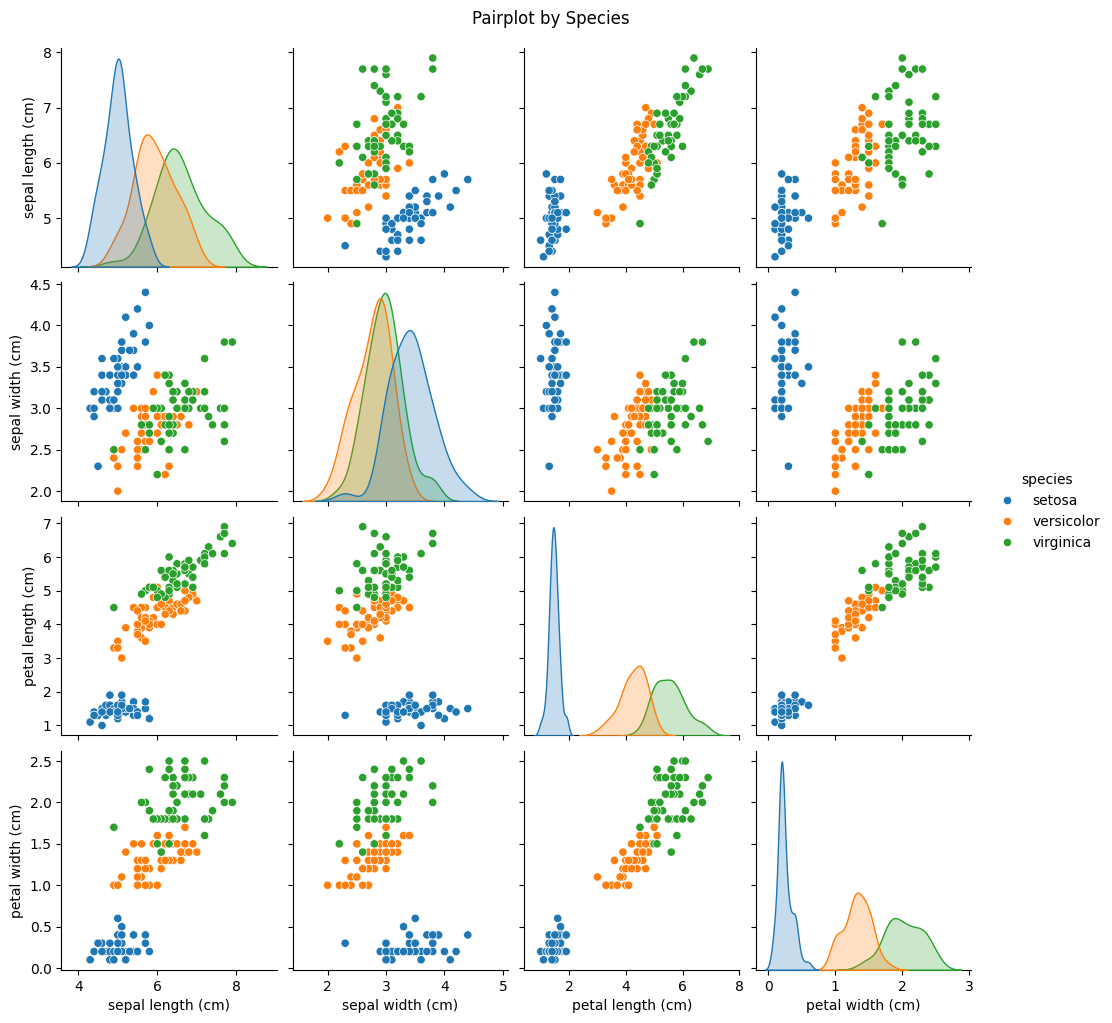

In [12]:
sns.pairplot(df, hue='species')
plt.suptitle("Pairplot by Species", y=1.02)
plt.show()

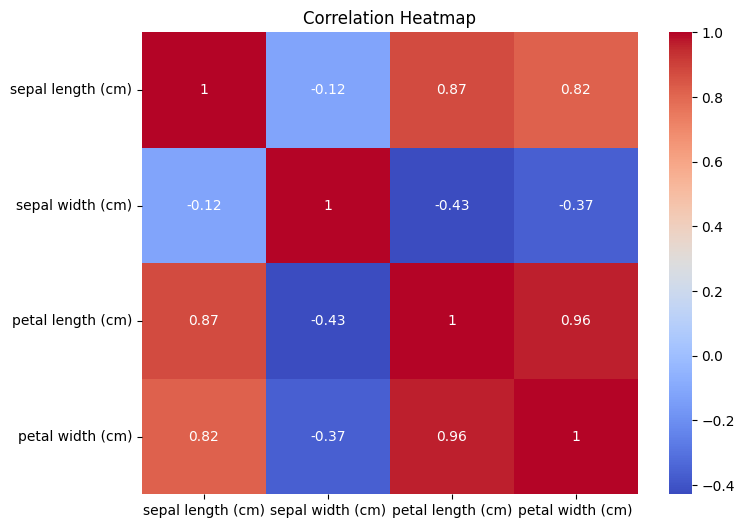

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

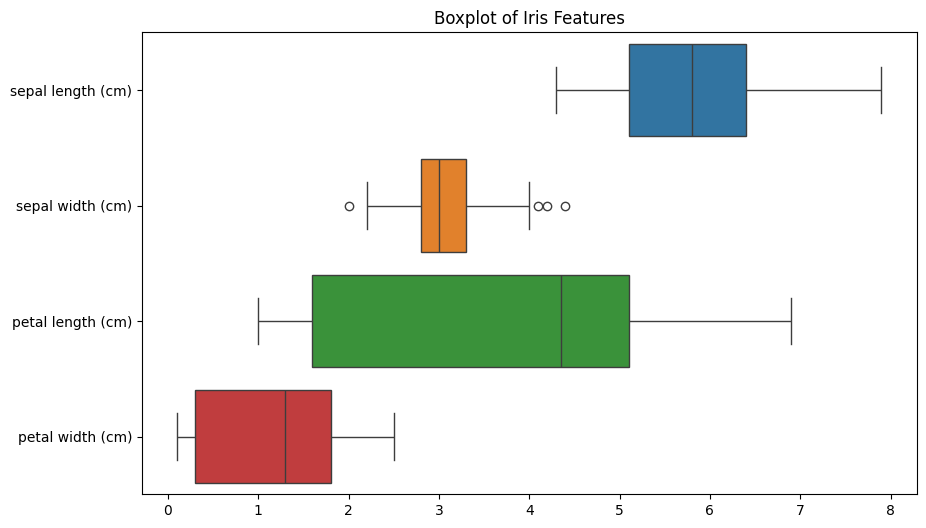

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of Iris Features")
plt.show()

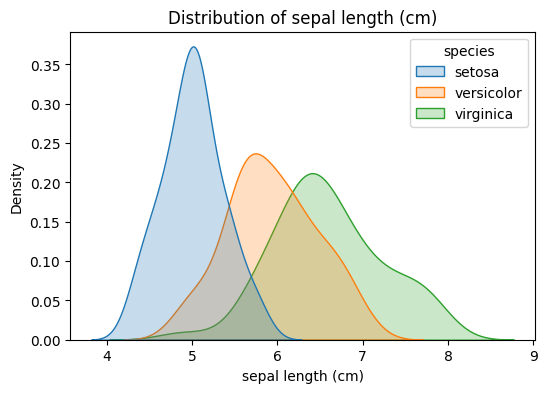

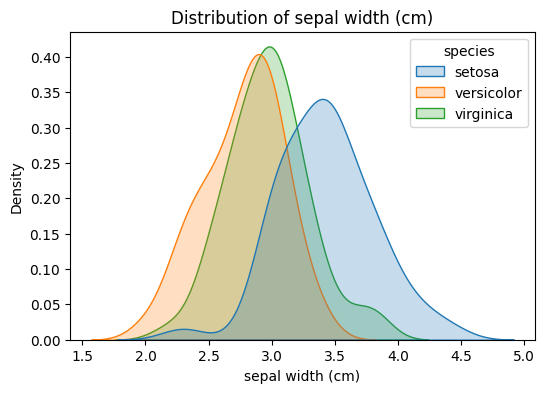

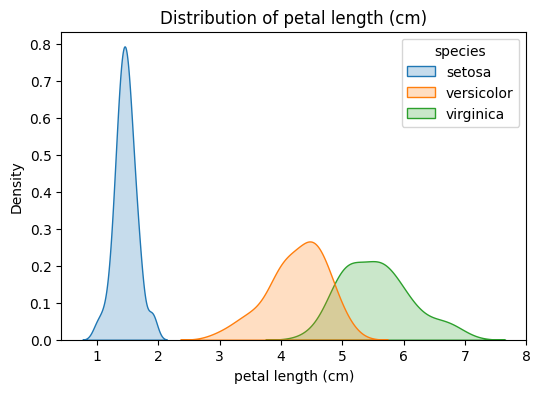

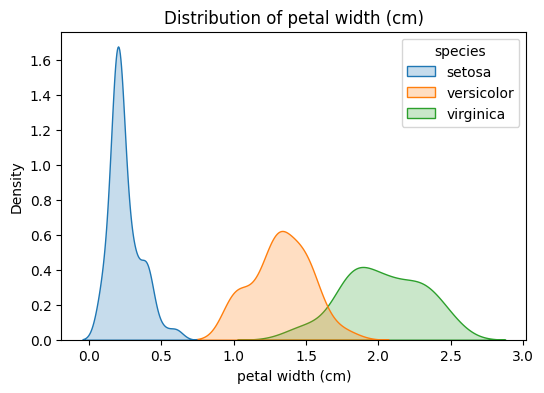

In [15]:
features = df.columns[:-1]
for feature in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=feature, hue="species", fill=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

In [16]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


# Data Preparation

In [19]:
#duplicate
df.duplicated().sum()

np.int64(1)

In [20]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [32]:
#encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [33]:
#pisah fitur dan label
X = df.drop('species', axis=1)
y = df['species']

In [34]:
#normalisasi
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
#split data jadi train dan test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modeling

In [36]:
#membangun model ann
model = Sequential()
model.add(Dense(8, activation='relu', input_shape=(4,)))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
#compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

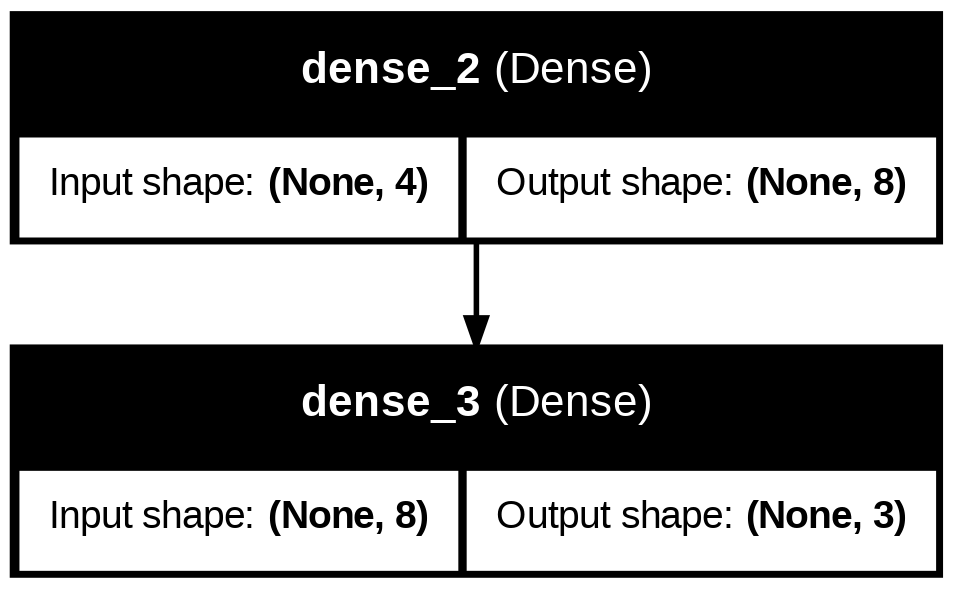

In [38]:
#plot arsitektur
tf.keras.utils.plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

In [39]:
# Konversi ke tipe data numerik
X_train = np.array(X_train).astype('float32')
X_test = np.array(X_test).astype('float32')
y_train = np.array(y_train).astype('float32')
y_test = np.array(y_test).astype('float32')

In [40]:
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2676 - loss: 1.1855 - val_accuracy: 0.3000 - val_loss: 1.1460
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3192 - loss: 1.1162 - val_accuracy: 0.3000 - val_loss: 1.1001
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3418 - loss: 1.0887 - val_accuracy: 0.3000 - val_loss: 1.0543
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3659 - loss: 1.0248 - val_accuracy: 0.3667 - val_loss: 1.0132
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3985 - loss: 1.0317 - val_accuracy: 0.5000 - val_loss: 0.9733
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4486 - loss: 0.9786 - val_accuracy: 0.5333 - val_loss: 0.9373
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6639 - loss: 0.9271 - val_accuracy: 0.6333 - val_loss: 0.9006
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5397 - loss: 0.9227 - val_accuracy: 0.7667 - 

# Evaluation

In [41]:
#model evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9667 - loss: 0.1416
Test Loss: 0.1416
Test Accuracy: 0.9667


# Deployment

## Model Simulation

In [42]:
data_baru = np.array([
    [5.0, 3.4, 1.5, 0.2],
    [6.0, 2.7, 4.1, 1.0],
    [6.5, 3.0, 5.5, 2.0]
])

data_baru_scaled = scaler.transform(data_baru)
prediksi_baru = model.predict(data_baru_scaled)
prediksi_baru_classes = np.argmax(prediksi_baru, axis=1)
class_names = ['setosa', 'versicolor', 'virginica']
print("\nHasil Simulasi Prediksi untuk Data Baru:")
for i, pred in enumerate(prediksi_baru_classes):
    print(f"Sampel {i+1}: {data_baru[i]} -> Prediksi: {class_names[pred]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Hasil Simulasi Prediksi untuk Data Baru:
Sampel 1: [5.  3.4 1.5 0.2] -> Prediksi: setosa
Sampel 2: [6.  2.7 4.1 1. ] -> Prediksi: versicolor
Sampel 3: [6.5 3.  5.5 2. ] -> Prediksi: virginica


## Save Model

In [45]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [47]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpgfs95fs0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138456195145296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138456195144912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138456195145104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138456195143952: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [48]:
with open('iris_model.tflite', 'wb') as f:
    f.write(tflite_model)

In [49]:
print("Model berhasil dikonversi dan disimpan sebagai iris_model.tflite")

Model berhasil dikonversi dan disimpan sebagai iris_model.tflite
